**Tarea** Notebook preprocesamiento

*Introducción a Ciencia de datos*

***María Guadalupe Villanueva Utrilla***

## Procedencia del dataset

El dataset **Breast Cancer Wisconsin** fue obtenido del **UCI Machine Learning Repository**. La documentación oficial del repositorio indica el orden y significado de cada columna, así también como que la variable `class` usa el valor 2 para casos benignos y 4 para casos malignos.

El conjunto fue dado originalmente por William H. Wolberg y actualmente se distribuye bajo la licencia **CC BY 4.0**, que permite su uso y adaptación siempre que se cite la fuente original.


## Objetivo

En esta práctica se trabaja con el dataset de breast cancer Wisconsin para realizar un análisis exploratorio y se aplican tres tipos de procesamiento:

- limpieza de datos,
- extracción de características,
- reducción de dimensionalidad.

También se comparan gráficamente los datos antes y después de cada técnica.

No se realizará aumento de datos. Al tratarse de datos clínicos, preferí conservar únicamente las observaciones originales y evitar generar registros artificiales sin una justificación médica y estadística más profunda.

In [1]:
import pandas as pd                                  #
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler     # estandarización antes de pca
from sklearn.decomposition import PCA                # reducción de dimensionalidad

columnas = [
    "id",
    "clump_thickness",
    "uniformity_cell_size",
    "uniformity_cell_shape",
    "marginal_adhesion",
    "single_epithelial_cell_size",
    "bare_nuclei",
    "bland_chromatin",
    "normal_nucleoli",
    "mitoses",
    "class"
]

ruta = "breast-cancer-wisconsin.data"
df = pd.read_csv(ruta, header=None, names=columnas)   # carga el archivo y asigna nombres
df.head()

,id,clump_thickness,uniformity_cell_size,uniformity_cell_shape,marginal_adhesion,single_epithelial_cell_size,bare_nuclei,bland_chromatin,normal_nucleoli,mitoses,class
0,1000025,5,1,1,1,2,1,3,1,1,2
1,1002945,5,4,4,5,7,10,3,2,1,2
2,1015425,3,1,1,1,2,2,3,1,1,2
3,1016277,6,8,8,1,3,4,3,7,1,2
4,1017023,4,1,1,3,2,1,3,1,1,2


### Análisis

El archivo se cargó correctamente y ya tiene nombres de columnas para que sea más fácil trabajar con él. Cada fila representa una muestra y la columna `class` indica el diagnóstico: 2 corresponde a benigno y 4 a maligno.

In [2]:
print("dimensiones:", df.shape)                      # muestra filas y columnas
print("\ntipos de datos:")
print(df.dtypes)
print("\nresumen general:")
display(df.describe(include="all"))

dimensiones: (699, 11)

tipos de datos:
id                              int64
clump_thickness                 int64
uniformity_cell_size            int64
uniformity_cell_shape           int64
marginal_adhesion               int64
single_epithelial_cell_size     int64
bare_nuclei                    object
bland_chromatin                 int64
normal_nucleoli                 int64
mitoses                         int64
class                           int64
dtype: object

resumen general:


,id,clump_thickness,uniformity_cell_size,uniformity_cell_shape,marginal_adhesion,single_epithelial_cell_size,bare_nuclei,bland_chromatin,normal_nucleoli,mitoses,class
count,6.990000e+02,699.000000,699.000000,699.000000,699.000000,699.000000,699,699.000000,699.000000,699.000000,699.000000
unique,NaN,NaN,NaN,NaN,NaN,NaN,11,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,402,NaN,NaN,NaN,NaN
mean,1.071704e+06,4.417740,3.134478,3.207439,2.806867,3.216023,NaN,3.437768,2.866953,1.589413,2.689557
std,6.170957e+05,2.815741,3.051459,2.971913,2.855379,2.214300,NaN,2.438364,3.053634,1.715078,0.951273
min,6.163400e+04,1.000000,1.000000,1.000000,1.000000,1.000000,NaN,1.000000,1.000000,1.000000,2.000000
25%,8.706885e+05,2.000000,1.000000,1.000000,1.000000,2.000000,NaN,2.000000,1.000000,1.000000,2.000000
50%,1.171710e+06,4.000000,1.000000,1.000000,1.000000,2.000000,NaN,3.000000,1.000000,1.000000,2.000000
75%,1.238298e+06,6.000000,5.000000,5.000000,4.000000,4.000000,NaN,5.000000,4.000000,1.000000,4.000000


### Análisis

El dataset contiene 699 registros y 11 columnas. Casi todas las variables son numéricas, pero `bare_nuclei` aparece como tipo objeto. Esto hace pensar que contiene algún valor que no es numérico y que sería conveniente revisarlo antes de seguir.

valores '?' por columna:
bare_nuclei    16
dtype: int64

filas duplicadas exactas: 8

distribución de clases:
class
2    458
4    241
Name: count, dtype: int64


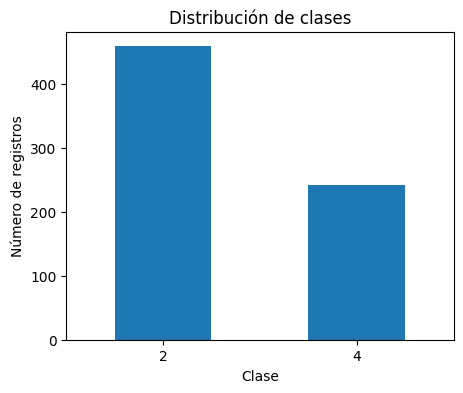

In [3]:
faltantes_simbolicos = (df == "?").sum()             # cuenta los signos ? por columna
duplicados = df.duplicated().sum()                   # cuenta filas iguales
clases = df["class"].value_counts().sort_index()      # cuenta casos por clase

print("valores '?' por columna:")
print(faltantes_simbolicos[faltantes_simbolicos > 0])
print("\nfilas duplicadas exactas:", duplicados)
print("\ndistribución de clases:")
print(clases)

plt.figure(figsize=(5, 4))
clases.plot(kind="bar")
plt.title("Distribución de clases")
plt.xlabel("Clase")
plt.ylabel("Número de registros")
plt.xticks(rotation=0)
plt.show()

### Análisis

Se encontraron 16 valores representados con `?` en `bare_nuclei`, por eso esa columna no se había reconocido como numérica. También hay 8 filas duplicadas.

La clase 2 tiene más registros que la clase 4. No es un desbalance muy grande, pero sí conviene tenerlo en cuenta cuando se haga el análisis final.

## 1. Limpieza de datos

Se harán dos cambios:

1. Convertir los `?` de `bare_nuclei` en valores faltantes y cqmbiarlos con la mediana,
2. eliminar filas duplicadas.

Se usa la mediana porque la variable toma valores discretos entre 1 y 10, y así se evita perder las 16 observaciones.

In [4]:
antes_faltantes = (df["bare_nuclei"] == "?").sum()   # cantidad antes de limpiar
antes_filas = len(df)                                 # filas antes de eliminar duplicados

df_limpio = df.copy()
df_limpio["bare_nuclei"] = pd.to_numeric(
    df_limpio["bare_nuclei"].replace("?", np.nan)
)                                                     # convierte ? en nan y luego a número

mediana_bare = df_limpio["bare_nuclei"].median()      # obtiene un valor central
df_limpio["bare_nuclei"] = df_limpio["bare_nuclei"].fillna(mediana_bare)
df_limpio = df_limpio.drop_duplicates().reset_index(drop=True)  # quita duplicados

despues_faltantes = df_limpio["bare_nuclei"].isna().sum()
despues_filas = len(df_limpio)

print("mediana usada:", mediana_bare)
print("filas antes:", antes_filas)
print("filas después:", despues_filas)
print("faltantes antes:", antes_faltantes)
print("faltantes después:", despues_faltantes)

mediana usada: 1.0
filas antes: 699
filas después: 690
faltantes antes: 16
faltantes después: 0


### Análisis

La mediana de `bare_nuclei` fue 1.0 y se empleó para completar los 16 valores faltantes. Después de eliminar duplicados quedaron 690 registros. Con esto ya todos sus datos pueden tratarse como números.

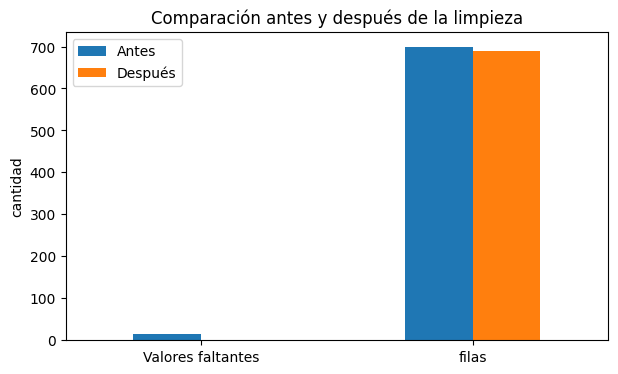

In [5]:
comparacion_limpieza = pd.DataFrame({
    "Antes": [antes_faltantes, antes_filas],
    "Después": [despues_faltantes, despues_filas]
}, index=["Valores faltantes", "filas"])

comparacion_limpieza.plot(kind="bar", figsize=(7, 4))
plt.title("Comparación antes y después de la limpieza")
plt.ylabel("cantidad")
plt.xticks(rotation=0)
plt.show()

### análisis

La comparación muestra que los valores faltantes quedaron en cero. El número total de filas se disminuyó solo por eliminar los duplicados, por lo que la limpieza no eliminó registros debido a los datos faltantes.

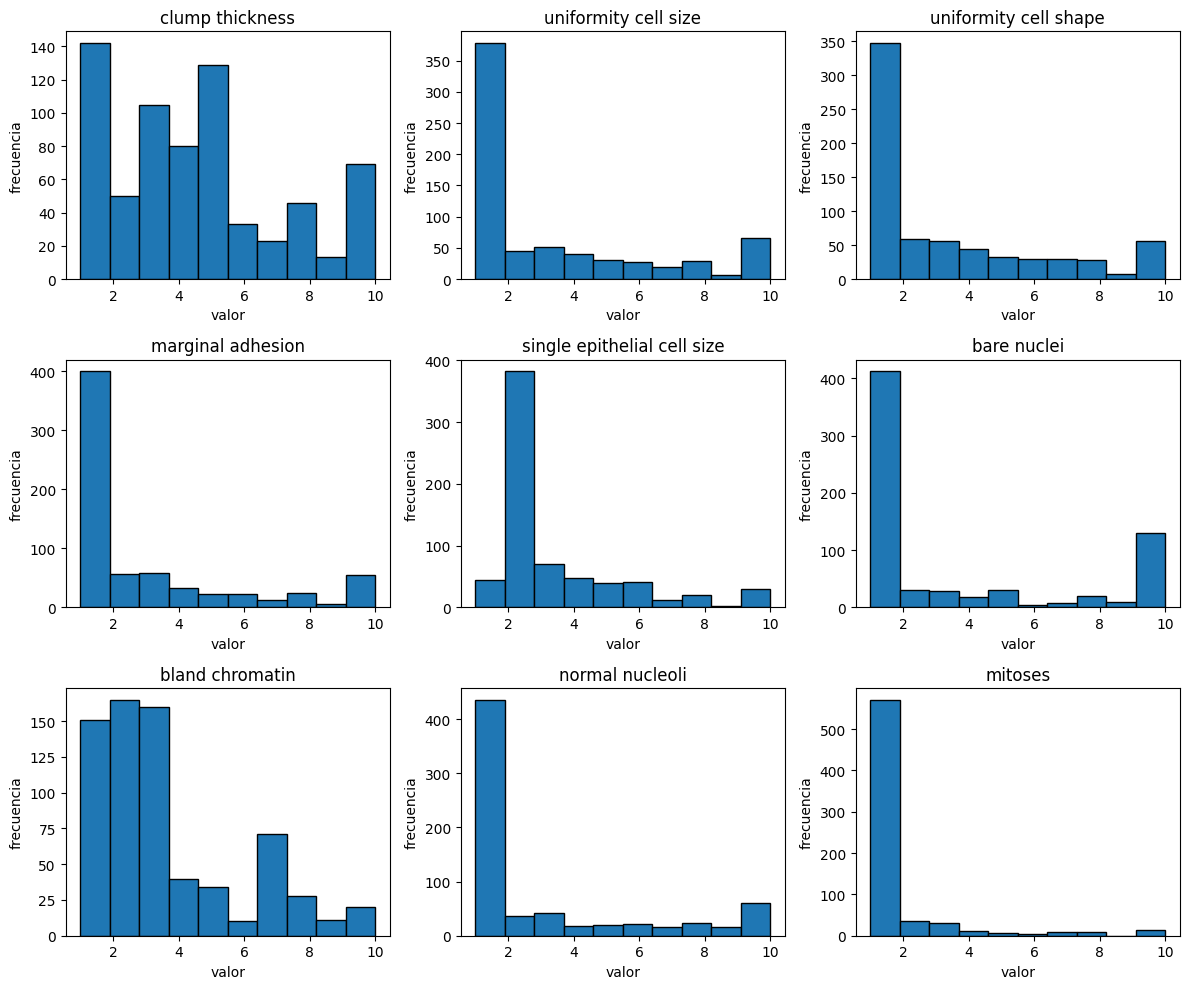

In [6]:
variables = [
    "clump_thickness",
    "uniformity_cell_size",
    "uniformity_cell_shape",
    "marginal_adhesion",
    "single_epithelial_cell_size",
    "bare_nuclei",
    "bland_chromatin",
    "normal_nucleoli",
    "mitoses"
]

fig, axes = plt.subplots(3, 3, figsize=(12, 10))
axes = axes.flatten()

for i, variable in enumerate(variables):
    axes[i].hist(df_limpio[variable], bins=10, edgecolor="black")
    axes[i].set_title(variable.replace("_", " "))
    axes[i].set_xlabel("valor")
    axes[i].set_ylabel("frecuencia")

plt.tight_layout()
plt.show()

### Análisis

En varias variables se observa una concentración en valores bajos, especialmente en `mitoses. EN otras como la uniformidad del tamaño y de la forma celular, tienen una mayor presencia de valores altos. Estas diferencias pueden servir para separar a las dos clases.

##2. Extracción de características

Como una extracción, se crea una nueva característica llamada `mean_cell_uniformity`. Esta variable será el promedio entre `uniformity_cell_size` y `uniformity_cell_shape`.

ESto para resumir en un solo valor dos mediciones que describen qué tan uniformes son las células.

In [7]:
df_features = df_limpio.copy()

df_features["mean_cell_uniformity"] = (
    df_features["uniformity_cell_size"] +
    df_features["uniformity_cell_shape"]
) / 2                                                   # resume las dos medidas de uniformidad

df_features[
    ["uniformity_cell_size", "uniformity_cell_shape", "mean_cell_uniformity"]
].head()

,uniformity_cell_size,uniformity_cell_shape,mean_cell_uniformity
0,1,1,1.0
1,4,4,4.0
2,1,1,1.0
3,8,8,8.0
4,1,1,1.0


### Análisis

La nueva característica conserva la información general de las dos variables originales en una medida más compacta. Si ambas variables tienen valores bajos, entonces el promedio también será bajo; si ambas aumentan, la nueva característica también lo hará

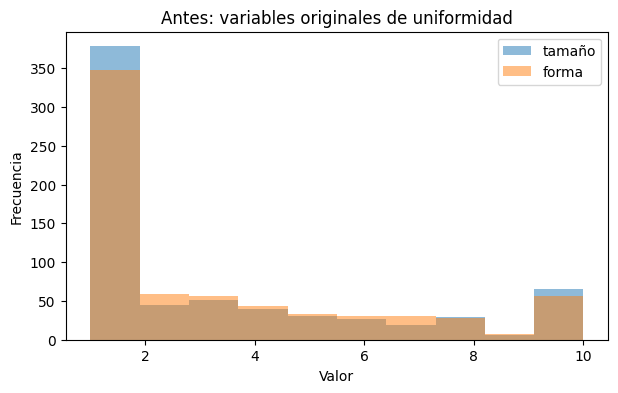

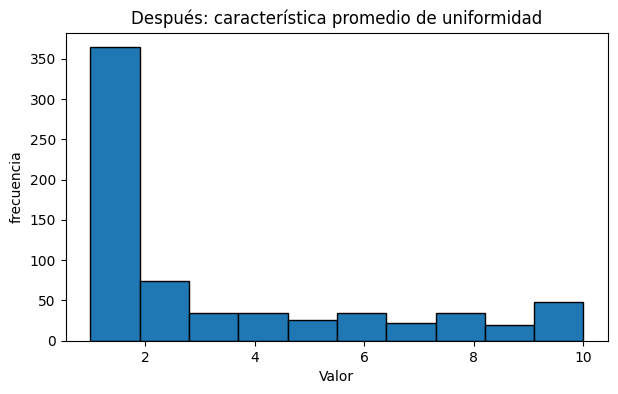

In [8]:
plt.figure(figsize=(7, 4))
plt.hist(df_features["uniformity_cell_size"], bins=10, alpha=0.5, label="tamaño")
plt.hist(df_features["uniformity_cell_shape"], bins=10, alpha=0.5, label="forma")
plt.title("Antes: variables originales de uniformidad")
plt.xlabel("Valor")
plt.ylabel("Frecuencia")
plt.legend()
plt.show()

plt.figure(figsize=(7, 4))
plt.hist(df_features["mean_cell_uniformity"], bins=10, edgecolor="black")
plt.title("Después: característica promedio de uniformidad")
plt.xlabel("Valor")
plt.ylabel("frecuencia")
plt.show()

### ANálisis

Antes se tenían dos distribuciones muy parecidas para tamaño y forma celular. Después se tiene en una sola distribución que resume su comportamiento. Esto reduce un poco la redundancia sin borrar las variables originales del dataset.

In [9]:
promedio_por_clase = df_features.groupby("class")[
    ["uniformity_cell_size", "uniformity_cell_shape", "mean_cell_uniformity"]
].mean()

display(promedio_por_clase)

,uniformity_cell_size,uniformity_cell_shape,mean_cell_uniformity
class,,,
2,1.329646,1.449115,1.389381
4,6.558824,6.537815,6.548319


### Análisis

El promedio de uniformidad es menor en la clase 2 que en la clase 4. Esto dice que la característica creada conserva una diferencia visible entre los dos grupos y puede ser informativa para un análisis posterior a este

## 3. Reducción de dimensionalidad con PCA

El dataset tiene varias variables que describen características celulares. Para verlo en solo dos dimensiones se aplica pca.

Antes de PCA se estandarizan las variables para que todas queden en una escala comparable. La columna `id` no se usa porque funciona como identificador y no como una medición clínica

In [10]:
x = df_features[variables].copy()                       # selecciona solo variables de entrada
y = df_features["class"].copy()                         # guarda la clase para colorear la gráfica

escalador = StandardScaler()
x_escalado = escalador.fit_transform(x)                 # centra y escala las variables

pca = PCA(n_components=2)
x_pca = pca.fit_transform(x_escalado)                   # reduce nueve variables a dos componentes

df_pca = pd.DataFrame(x_pca, columns=["pc1", "pc2"])
df_pca["class"] = y.values

print("varianza explicada por pc1:", round(pca.explained_variance_ratio_[0], 3))
print("varianza explicada por pc2:", round(pca.explained_variance_ratio_[1], 3))
print("varianza total:", round(pca.explained_variance_ratio_.sum(), 3))

varianza explicada por pc1: 0.656
varianza explicada por pc2: 0.086
varianza total: 0.742


### Análisis

Los dos primeros componentes tienen una parte grande de la variación total del dataset. Entonces se pueden representar las nueve variables originales en un plano (dos dimensiones), aunque se pierde parte de la información

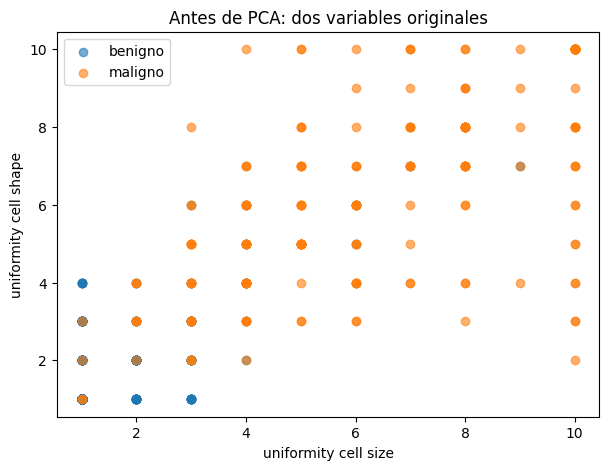

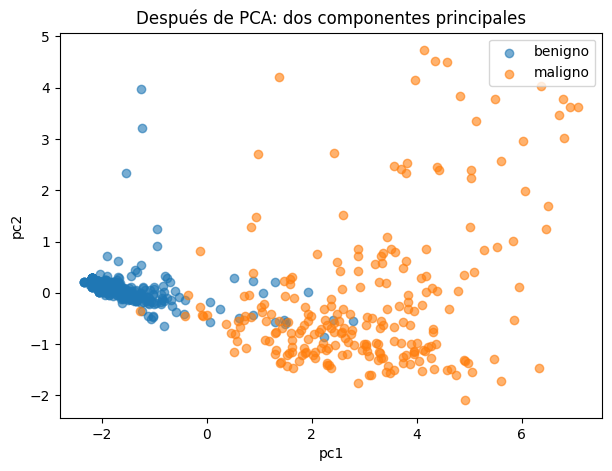

In [11]:
plt.figure(figsize=(7, 5))

for clase, etiqueta in [(2, "benigno"), (4, "maligno")]:
    grupo = df_features[df_features["class"] == clase]
    plt.scatter(
        grupo["uniformity_cell_size"],
        grupo["uniformity_cell_shape"],
        alpha=0.6,
        label=etiqueta
    )

plt.title("Antes de PCA: dos variables originales")
plt.xlabel("uniformity cell size")
plt.ylabel("uniformity cell shape")
plt.legend()
plt.show()

plt.figure(figsize=(7, 5))

for clase, etiqueta in [(2, "benigno"), (4, "maligno")]:
    grupo = df_pca[df_pca["class"] == clase]
    plt.scatter(grupo["pc1"], grupo["pc2"], alpha=0.6, label=etiqueta)

plt.title("Después de PCA: dos componentes principales")
plt.xlabel("pc1")
plt.ylabel("pc2")
plt.legend()
plt.show()

### Análisis

En la gráfica original solo se comparan dos variables. Con PCA se combinan las nueve características numéricas y se obtiene una representación de dos dimensiones.

En la gráfica reducida se aprecia una separación general entre muchos casos benignos y malignos aunque también existe una zona donde ambos grupos se mezclan. Esto tiene sentido porque PCA busca resumir la variabilidad y no clasificar de manera directa.

## Conclusión

El análisis permitió identificar valores faltantes representados con `?`, registros duplicados y una diferencia en la cantidad de casos de cada clase.

La limpieza dejó las variables listas para trabajar de forma numérica. Después se creó una característica promedio para resumir la uniformidad celular y finalmente se aplicó pca para representar el conjunto de variables en dos dimensiones.

No se realizó aumento de datos porque se trata de información clínica. Consideré adecuado conservar los registros originales y evitar crear observaciones artificiales que podrían introducir patrones que no vienen de pacientes reales.


**Declaración sobre el Uso de Inteligencia Artificial**

Para la realización de esta práctica se utilizó *Gemini (Google AI*) como herramienta de soporte técnico, pedagógico y de redacción.
Alcance de uso:
* Búsqueda de información de dataset y cómo interpretar sus columnas.
* Soporte de código y resolución de errores
  * Sugerencia de uso de la librería sklearn.preprocessing import (StandardScaler) para la estandarización antes de PCA y sklearn.decomposition (PCA).    
* Supervisión de formato de texto.
* Sugerencia de característica añadida.
* Revisión de licencia.
